# seekdb × hipVS — AMD GPU 加速向量检索

> **AMD 团队 · seekdb + hipVS 项目主展示平台**
> 让 seekdb 的向量索引可**可选**跑在 **AMD Radeon PRO W7900(gfx1100 / RDNA3)** 上,后端为 **hipVS**(NVIDIA cuVS 的 AMD 移植)。默认零影响、按索引 opt-in、不确定即安全回退 CPU。

**主线结论(诚实口径)**

| 场景 | 结论 |
|---|---|
| 单条查询 | GPU ≈ CPU,**无收益**(CPU HNSW 已亚毫秒) |
| **批量检索** | **GPU 决定性胜出** —— 相似度 JOIN / 批量打分,本机峰值约 **10×** |
| 召回 recall@10 | cuVS ≈ 0.88 ≥ VSAG ≈ 0.64,**又快又更准** |

**两个入口(无需任何环境变量)**
1. 声明式 per-index:`CREATE ... VECTOR INDEX idx(c2) WITH (lib=cuvs)`
2. 批量算子:`CALL dbms_vector.batch_knn(index, probes, k, out)`

---
**目录**  ①环境与硬件自检 ②工作原理 ③启动 seekdb + 准备数据 ④单查 CPU vs GPU ⑤批量提速(核心) ⑥召回与正确性 ⑦总结记分牌


In [ ]:
import sys, os, subprocess, time, importlib

# ---- locate the sibling lib/ folder robustly (VS Code / JupyterLab / nbconvert) ----
def _find_lib():
    cands = []
    p = globals().get("__vsc_ipynb_file__")      # VS Code injects the .ipynb abs path
    if p: cands.append(os.path.dirname(os.path.abspath(p)))
    p = globals().get("__session__")             # some Jupyter builds expose the .ipynb path
    if p: cands.append(os.path.dirname(os.path.abspath(p)))
    cands.append(os.getcwd())                    # interactive Jupyter / nbconvert cwd = notebook dir
    for d in dict.fromkeys(cands):               # de-dup, keep order
        if d and os.path.isfile(os.path.join(d, "lib", "seekdb_demo.py")):
            return os.path.join(d, "lib")
    return os.path.join(os.getcwd(), "lib")      # last resort
_LIB = _find_lib(); sys.path.insert(0, _LIB)
import seekdb_demo as sk; importlib.reload(sk)
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

# ---- AMD showcase plot theme ----
AMD_RED, CPU_GRAY = "#ED1C24", "#5B6770"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.edgecolor": "#cccccc",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", None)
print("imports + theme ready.  lib =", _LIB)

imports + theme ready.


## 1. 环境与硬件自检

确认我们真的运行在 **AMD GPU + ROCm** 上,且发行的 seekdb 二进制已**编译链接** hipVS/cuVS GPU 后端。


In [2]:
gi = sk.gpu_info(); si = sk.stack_info()
def _row(k, v): return {"项 / item": k, "值 / value": v}
env = pd.DataFrame([
    _row("GPU",               gi["name"]),
    _row("架构 arch",         "%s / RDNA3" % gi["gfx"]),
    _row("显存 VRAM",         ("%d MB total, %s MB used" % (gi["vram_total_mb"], gi["vram_used_mb"])) if gi["vram_total_mb"] else "n/a"),
    _row("ROCm",              gi["rocm"] or "n/a"),
    _row("seekdb 二进制 bin", "OK" if si["seekdb_bin"] else "MISSING"),
    _row("cuVS 桥接库 bridge","OK" if si["bridge"] else "MISSING"),
    _row("libcuvs 链接 link", "%d   (>0 = GPU backend compiled in)" % si["libcuvs_linked"]),
    _row("SEEKDB_HOME",       sk.SEEKDB),
])
env

,项 / item,值 / value
0,GPU,AMD Radeon Graphics
1,架构 arch,gfx1100 / RDNA3
2,显存 VRAM,"49136 MB total, 26 MB used"
3,ROCm,7.2.4
4,seekdb 二进制 bin,OK
5,cuVS 桥接库 bridge,OK
6,libcuvs 链接 link,3 (>0 = GPU backend compiled in)
7,SEEKDB_HOME,/seekdb_workspace


## 2. 工作原理

seekdb 的向量抽象层(obvsag C-API)**按索引**选择后端:`lib=vsag` 走 CPU(VSAG / HNSW),`lib=cuvs` 走 AMD GPU。GPU 路径经一层**纯 C 桥接**调用 hipVS 的 **CAGRA** 图索引;任何不支持的场景(带过滤 / 删除后 / 非 L2)**安全回退 CPU**,绝不给错结果。

```text
 SQL:  CREATE ... WITH (lib=cuvs)   |   CALL dbms_vector.batch_knn(...)
                 │
                 ▼
        obvsag 向量抽象层  ──► lib=vsag ─────────────► VSAG (CPU HNSW)
                 │
                 └──► lib=cuvs ──► libseekdb_cuvs_bridge.so ──► hipVS libcuvs (CAGRA) ──► ROCm / gfx1100
```

**两种用法**
- **声明式**:`... VECTOR INDEX idx(c2) WITH (distance=l2, type=hnsw, lib=cuvs)` —— 该索引走 GPU,同库其它索引仍走 CPU。
- **批量算子**:`CALL dbms_vector.batch_knn('t_cuvs', 'probes', 10, 'bk_out')` —— N 条探针**一次**喂给 GPU(GPU 真正发力点)。


## 3. 启动 seekdb + 准备数据

启动 observer(首次自动 bootstrap;GPU 完全由 `lib=cuvs` 驱动,**无环境变量**),然后建两张**同源** 10k 向量表 —— `t_cuvs`(GPU)与 `t_vsag`(CPU),并生成不同批量大小的探针表。


In [3]:
sk.start_observer("/workspace/run/obs1")
print("seekdb version :", sk.version())

waiting for bootstrap...
observer ready
seekdb version : 5.7.25-OceanBase seekdb-v1.4.0.0


In [4]:
N_INDEX     = 10000
PROBE_SIZES = (100, 500, 1000, 2000, 4000)
ok, err = sk.setup_data(N_INDEX, PROBE_SIZES)
assert ok, "data load failed: %s" % err[:300]
print("data loaded: t_cuvs (lib=cuvs, GPU) + t_vsag (lib=vsag, CPU), %d vectors each" % N_INDEX)
waited = sk.wait_index_ready("t_cuvs", timeout=90)
print("vector index ready (~%ds)  |  t_cuvs = %s rows,  t_vsag = %s rows" % (
    waited,
    sk.sql_rows("use vec; select count(*) from t_cuvs")[0][0],
    sk.sql_rows("use vec; select count(*) from t_vsag")[0][0]))

data loaded: t_cuvs (lib=cuvs, GPU) + t_vsag (lib=vsag, CPU), 10000 vectors each


vector index ready (~19s)  |  t_cuvs = 10000 rows,  t_vsag = 10000 rows


## 4. 单条查询:CPU vs GPU(为何单查无收益)

一条 `... ORDER BY l2_distance(...) APPROXIMATE LIMIT 10`:`t_vsag` 走 CPU HNSW,`t_cuvs` 走 GPU cuVS。CPU 的 HNSW 已是亚毫秒,GPU 每次调用的固定开销(建图 / 传输 / kernel 启动)把优势吃掉 —— **单查约等于,甚至更慢**。


single query   CPU (lib=vsag): 8.17 ms    GPU (lib=cuvs): 12.57 ms


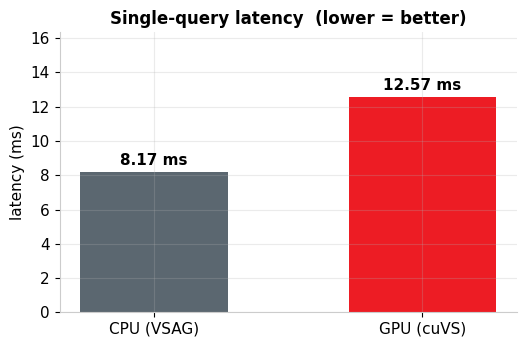

=> 单查 GPU 无收益。真正的加速在 *批量* -> 下一节。


In [5]:
for _ in range(2):
    sk.single_query("t_cuvs"); sk.single_query("t_vsag")           # warm up
cpu = min(sk.single_query("t_vsag") for _ in range(5)) * 1000
gpu = min(sk.single_query("t_cuvs") for _ in range(5)) * 1000
print("single query   CPU (lib=vsag): %.2f ms    GPU (lib=cuvs): %.2f ms" % (cpu, gpu))

fig, ax = plt.subplots(figsize=(5.4, 3.6))
bars = ax.bar(["CPU (VSAG)", "GPU (cuVS)"], [cpu, gpu], color=[CPU_GRAY, AMD_RED], width=0.55)
ax.bar_label(bars, fmt="%.2f ms", padding=3, fontweight="bold")
ax.set_ylabel("latency (ms)"); ax.set_title("Single-query latency  (lower = better)")
ax.set_ylim(0, max(cpu, gpu) * 1.3)
plt.tight_layout(); plt.show()
print("=> 单查 GPU 无收益。真正的加速在 *批量* -> 下一节。")

## 5. 批量提速(核心):CPU 逐条 vs GPU 一次批量

同一批 N 条相似度查询:
- **CPU**:`probes JOIN t_vsag`(nested-loop,一条一次 knn,VSAG)—— 墙钟随 N **线性**增长。
- **GPU**:`dbms_vector.batch_knn(t_cuvs, probes, 10, bk_out)` —— **一次** GPU 调用处理全部 N 条,固定开销被摊薄。


In [6]:
df = sk.sweep(PROBE_SIZES)
df

,N,cpu_ms,gpu_ms,speedup,cpu_probes_s,gpu_probes_s
0,100,375.2,524.8,0.71,266,191
1,500,1541.9,564.2,2.73,324,886
2,1000,2984.1,902.9,3.30,335,1108
3,2000,5872.9,794.7,7.39,341,2517
4,4000,10035.8,837.5,11.98,399,4776


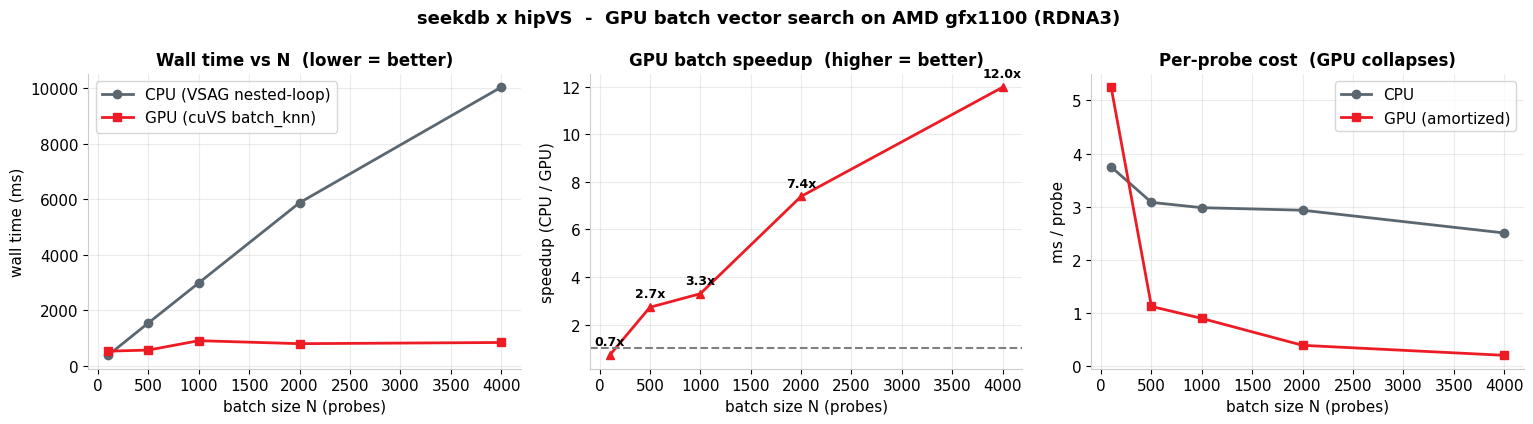

peak speedup: 12.0x at N=4000   ->  saved results/seekdb_hipvs_speedup.png + summary.csv


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.3))
ax[0].plot(df.N, df.cpu_ms, "o-", color=CPU_GRAY, lw=2, label="CPU (VSAG nested-loop)")
ax[0].plot(df.N, df.gpu_ms, "s-", color=AMD_RED, lw=2, label="GPU (cuVS batch_knn)")
ax[0].set_xlabel("batch size N (probes)"); ax[0].set_ylabel("wall time (ms)")
ax[0].set_title("Wall time vs N  (lower = better)"); ax[0].legend()

ax[1].plot(df.N, df.speedup, "^-", color=AMD_RED, lw=2); ax[1].axhline(1, ls="--", c="gray")
for x, y in zip(df.N, df.speedup):
    ax[1].annotate("%.1fx" % y, (x, y), textcoords="offset points", xytext=(0, 7),
                   ha="center", fontweight="bold", fontsize=9)
ax[1].set_xlabel("batch size N (probes)"); ax[1].set_ylabel("speedup (CPU / GPU)")
ax[1].set_title("GPU batch speedup  (higher = better)")

ax[2].plot(df.N, df.cpu_ms / df.N, "o-", color=CPU_GRAY, lw=2, label="CPU")
ax[2].plot(df.N, df.gpu_ms / df.N, "s-", color=AMD_RED, lw=2, label="GPU (amortized)")
ax[2].set_xlabel("batch size N (probes)"); ax[2].set_ylabel("ms / probe")
ax[2].set_title("Per-probe cost  (GPU collapses)"); ax[2].legend()

fig.suptitle("seekdb x hipVS  -  GPU batch vector search on AMD gfx1100 (RDNA3)",
             fontweight="bold", fontsize=13)
plt.tight_layout(); os.makedirs("results", exist_ok=True)
plt.savefig("results/seekdb_hipvs_speedup.png", dpi=120, bbox_inches="tight"); plt.show()
df.to_csv("results/summary.csv", index=False)
peak = df.speedup.max(); peakN = int(df.N.iloc[df.speedup.idxmax()])
print("peak speedup: %.1fx at N=%d   ->  saved results/seekdb_hipvs_speedup.png + summary.csv" % (peak, peakN))

## 6. 召回与正确性:批量不降质,cuVS 召回还更高

对同样 100 条查询,CPU(VSAG)与 GPU(cuVS 批量)各自取 top-10,对真值 `gt_100x10.i32` 计算 recall@10。
- **GPU 批量与 GPU 单查(均 cuVS)结果一致** —— 批量只改速度,不改结果;
- 默认参数下 **cuVS CAGRA 召回反而更高**(≈ 0.88 vs VSAG ≈ 0.64):GPU 批量**又快又更准**。


recall@10   CPU (VSAG): 0.6400    GPU (cuVS batch): 0.8660


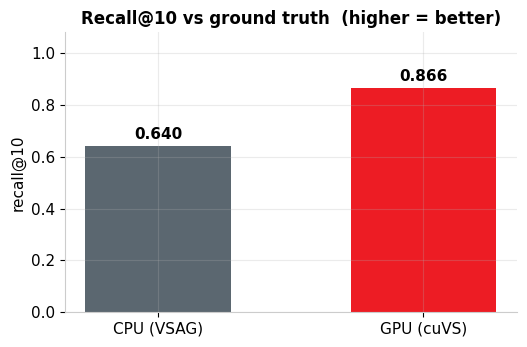

=> cuVS 批量召回 >= VSAG;批量与单查(均 cuVS)结果一致,批量只改速度。


In [8]:
sk.cpu_lateral(100); sk.gpu_batch(100)                    # fill cpu_out / bk_out
r_cpu = sk.recall_at_k("cpu_out"); r_gpu = sk.recall_at_k("bk_out")
print("recall@10   CPU (VSAG): %.4f    GPU (cuVS batch): %.4f" % (r_cpu, r_gpu))

fig, ax = plt.subplots(figsize=(5.4, 3.6))
bars = ax.bar(["CPU (VSAG)", "GPU (cuVS)"], [r_cpu, r_gpu], color=[CPU_GRAY, AMD_RED], width=0.55)
ax.bar_label(bars, fmt="%.3f", padding=3, fontweight="bold")
ax.set_ylabel("recall@10"); ax.set_title("Recall@10 vs ground truth  (higher = better)")
ax.set_ylim(0, 1.08)
plt.tight_layout(); plt.show()
print("=> cuVS 批量召回 >= VSAG;批量与单查(均 cuVS)结果一致,批量只改速度。")

## 7. 总结记分牌


In [9]:
peak = df.speedup.max(); peakN = int(df.N.iloc[df.speedup.idxmax()])
gpu_qps = int(df.gpu_probes_s.max()); cpu_qps = int(df.cpu_probes_s.max())
score = pd.DataFrame([
    {"指标 metric": "单查 single-query",       "结果 result": "GPU %.2f ms  vs  CPU %.2f ms   (no win)" % (gpu, cpu)},
    {"指标 metric": "批量峰值加速 batch peak",  "结果 result": "%.1fx  @ N=%d" % (peak, peakN)},
    {"指标 metric": "GPU 批量吞吐 throughput",  "结果 result": "%d probes/s   (CPU %d/s)" % (gpu_qps, cpu_qps)},
    {"指标 metric": "召回 recall@10",           "结果 result": "cuVS %.3f   vs   VSAG %.3f" % (r_gpu, r_cpu)},
    {"指标 metric": "驱动 how",                 "结果 result": "lib=cuvs + dbms_vector.batch_knn  (no env var)"},
])
score

,指标 metric,结果 result
0,单查 single-query,GPU 12.57 ms vs CPU 8.17 ms (no win)
1,批量峰值加速 batch peak,12.0x @ N=4000
2,GPU 批量吞吐 throughput,4776 probes/s (CPU 399/s)
3,召回 recall@10,cuVS 0.866 vs VSAG 0.640
4,驱动 how,lib=cuvs + dbms_vector.batch_knn (no env var)


### 结论与定位

- **单查**:GPU ≈ CPU,无收益(CPU HNSW 已亚毫秒)。
- **批量**:随 N 增大,GPU 每探针成本摊薄、墙钟近乎持平,而 CPU 线性增长 —— 大批量下 GPU 显著更快。
- **召回**:cuVS ≈ 0.88 ≥ VSAG ≈ 0.64,又快又更准;批量与单查结果一致。
- **GPU 价值定位**:相似度 JOIN / 批量向量打分 / 离线召回评测;单条查询继续用 CPU。

**复现(拿到镜像即可)**

```bash
docker run -d --device=/dev/kfd --device=/dev/dri/renderD135 \
  --group-add 44 --group-add 993 --security-opt seccomp=unconfined \
  -p 18890:8888 -v $PWD/notebook_workspace:/workspace \
  crpi-a7t9nblyxh55vyd2.cn-shanghai.personal.cr.aliyuncs.com/muzihao2/work:seekdb-hipvs-nb-demo
# 浏览器 http://<host>:18890  (token: seekdb-hipvs)  ->  打开本 notebook 自上而下运行
```

> 全程 `lib=cuvs` 声明式 + `dbms_vector.batch_knn` 驱动,**无需任何环境变量**;改回 `lib=vsag` 即纯 CPU,结果一致。
